# Módulo 5 — Reducción de varianza y Griegas por Monte Carlo

**Proyecto:** Métodos de Monte Carlo en Finanzas Cuantitativas
**Autor:** Jorge Rodríguez Lázaro
**Última actualización:** 2026-09-26

---

## Objetivo del módulo

Los módulos anteriores establecieron *qué* podemos calcular con Monte Carlo. Este trata del **oficio**: cómo hacerlo bien. Dos temas que separan a quien conoce Monte Carlo de quien lo domina:

1. **Reducción de varianza.** El error de Monte Carlo cae como $1/\sqrt{N}$ (Módulo 1): lento. En lugar de forzar más simulaciones, reducimos la *varianza* del estimador con el mismo $N$. Vemos dos técnicas —**variables antitéticas** y **variables de control**— y las aplicamos a un caso donde de verdad importan: la **opción asiática**, que no tiene fórmula cerrada.
2. **Griegas por Monte Carlo.** Las sensibilidades del precio (Delta, Gamma, Vega) son lo que una mesa usa para cubrir. Calcularlas por simulación tiene trampa, y comparamos los tres métodos estándar: **diferencias finitas**, **pathwise** y **razón de verosimilitud**.

Reutilizamos el paquete `mcquant` (`simular_gbm`, `black_scholes`) de los módulos anteriores.

## Estructura

| Sección | Tema | Idea clave |
|---------|------|------------|
| 1 | Variables antitéticas | Pares $(Z, -Z)$: correlación negativa que reduce la varianza gratis. |
| 2 | Variables de control | Usar una cantidad correlacionada de esperanza conocida. |
| 3 | Aplicación: opción asiática | La geométrica (con fórmula) como control de la aritmética (sin fórmula). |
| 4 | Griegas por Monte Carlo | Diferencias finitas vs. pathwise vs. razón de verosimilitud. |

## Referencias

- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*, caps. 4 y 7.
- Kemna, A. & Vorst, A. (1990). *A Pricing Method for Options Based on Average Asset Values*. J. Banking & Finance.
- Broadie, M. & Glasserman, P. (1996). *Estimating Security Price Derivatives Using Simulation*. Management Science.

> **Nota sobre el código.** Reutiliza el paquete `mcquant`; las técnicas nuevas de este módulo se implementan *inline* con fines didácticos.

---

# Sección 1 — Variables antitéticas

## 1.1 La idea

El estimador Monte Carlo de un precio es un promedio $\hat V = \frac{1}{N}\sum g(Z_i)$ con $Z_i \sim \mathcal{N}(0,1)$. Su varianza es $\operatorname{Var}(g)/N$. Las **variables antitéticas** explotan una simetría: si $Z$ es normal estándar, $-Z$ **también** lo es. Así, por cada $Z_i$ evaluamos el payoff en $Z_i$ y en $-Z_i$, y promediamos el par:

$$
\hat V_{\text{ant}} = \frac{1}{N/2}\sum_{i=1}^{N/2} \frac{g(Z_i) + g(-Z_i)}{2}
$$

La varianza de cada par es

$$
\operatorname{Var}\!\left(\frac{g(Z) + g(-Z)}{2}\right) = \frac{1}{2}\operatorname{Var}(g)\big(1 + \rho\big), \qquad \rho = \operatorname{Corr}(g(Z), g(-Z))
$$

Si $g$ es **monótona** (como el payoff de una call en $Z$), entonces $g(Z)$ y $g(-Z)$ están **negativamente correlados** ($\rho < 0$), y la varianza del par baja. La técnica es gratis: no cuesta simulaciones extra, solo reutiliza cada normal con signo cambiado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from mcquant import black_scholes, simular_gbm

rng = np.random.default_rng(seed=42)

S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.20, 1.0


def call_plain(S0, K, r, sigma, T, N, rng):
    Z = rng.standard_normal(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    disc = np.exp(-r * T) * np.maximum(ST - K, 0.0)
    return disc.mean(), disc.std(ddof=1) / np.sqrt(N)


def call_antitetico(S0, K, r, sigma, T, N, rng):
    Z = rng.standard_normal(N // 2)
    exponente = (r - 0.5 * sigma**2) * T
    ST_p = S0 * np.exp(exponente + sigma * np.sqrt(T) * Z)
    ST_m = S0 * np.exp(exponente - sigma * np.sqrt(T) * Z)   # antitética: -Z
    pares = 0.5 * (np.maximum(ST_p - K, 0.0) + np.maximum(ST_m - K, 0.0))
    disc = np.exp(-r * T) * pares
    return disc.mean(), disc.std(ddof=1) / np.sqrt(N // 2)

## 1.2 Cuánto se gana

Comparamos, con el **mismo número total de simulaciones**, el error estándar del estimador plano y del antitético. El *factor de reducción de varianza* es el cuadrado del cociente de errores estándar.

In [2]:
N = 1_000_000
bs = black_scholes(S0, K, r, sigma, T, 'call')

p_plain, se_plain = call_plain(S0, K, r, sigma, T, N, rng)
p_anti,  se_anti  = call_antitetico(S0, K, r, sigma, T, N, rng)

print(f"Black-Scholes exacto:       {bs:.4f}")
print(f"MC plano:        {p_plain:.4f}   SE = {se_plain:.5f}")
print(f"MC antitético:   {p_anti:.4f}   SE = {se_anti:.5f}")
print(f"\nFactor de reducción de varianza: {(se_plain/se_anti)**2:.2f}×")
print(f"Correlación g(Z), g(-Z):         {np.corrcoef(*(lambda Z: (np.maximum(S0*np.exp((r-0.5*sigma**2)*T+sigma*np.sqrt(T)*Z)-K,0), np.maximum(S0*np.exp((r-0.5*sigma**2)*T-sigma*np.sqrt(T)*Z)-K,0)))(rng.standard_normal(100_000)))[0,1]:.3f}")

Black-Scholes exacto:       10.4506
MC plano:        10.4532   SE = 0.01473
MC antitético:   10.4450   SE = 0.01037

Factor de reducción de varianza: 2.02×
Correlación g(Z), g(-Z):         -0.500


---

# Sección 2 — Variables de control

## 2.1 La idea

Supongamos que queremos estimar $\mathbb{E}[Y]$ (el precio) y disponemos de otra variable $X$ **correlacionada con $Y$** y de **esperanza conocida** $\mathbb{E}[X]$. Entonces, para cualquier coeficiente $\beta$:

$$
Y^\star = Y - \beta\,\big(X - \mathbb{E}[X]\big)
$$

tiene la **misma esperanza** que $Y$ (porque $\mathbb{E}[X - \mathbb{E}[X]] = 0$), pero podemos elegir $\beta$ para **minimizar su varianza**. El óptimo es

$$
\beta^\star = \frac{\operatorname{Cov}(Y, X)}{\operatorname{Var}(X)}, \qquad \operatorname{Var}(Y^\star) = \operatorname{Var}(Y)\,(1 - \rho_{XY}^2)
$$

Cuanto más correlacionados estén $X$ e $Y$, mayor la reducción. Si $\rho_{XY} = 0.99$, la varianza cae un factor $\sim 50$. La variable $X$ actúa como un "control" que absorbe el ruido común.

El arte está en encontrar un buen control: algo muy correlacionado con el payoff y cuya esperanza sepamos exactamente. Lo ilustramos primero con un control trivial y luego con el ejemplo estrella.

## 2.2 Un control sencillo: el propio subyacente

Para una call, un control natural es $X = S_T$, cuya esperanza conocemos exactamente bajo la medida neutral al riesgo: $\mathbb{E}^{\mathbb{Q}}[S_T] = S_0 e^{rT}$. El payoff de la call está correlacionado con $S_T$, así que sirve de control (imperfecto, pero gratis).

In [3]:
def call_control_ST(S0, K, r, sigma, T, N, rng):
    Z = rng.standard_normal(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    Y = np.exp(-r * T) * np.maximum(ST - K, 0.0)   # payoff descontado
    X = ST                                          # control
    EX = S0 * np.exp(r * T)                         # E[S_T] conocida
    beta = np.cov(Y, X, ddof=1)[0, 1] / np.var(X, ddof=1)
    Y_star = Y - beta * (X - EX)
    return Y_star.mean(), Y_star.std(ddof=1) / np.sqrt(N), np.corrcoef(Y, X)[0, 1]

p_ctrl, se_ctrl, rho = call_control_ST(S0, K, r, sigma, T, N, rng)
print(f"MC con control S_T:  {p_ctrl:.4f}   SE = {se_ctrl:.5f}")
print(f"Correlación payoff–S_T: {rho:.3f}")
print(f"Factor de reducción vs. MC plano: {(se_plain/se_ctrl)**2:.2f}×")

MC con control S_T:  10.4468   SE = 0.00561
Correlación payoff–S_T: 0.925
Factor de reducción vs. MC plano: 6.90×


---

# Sección 3 — La aplicación estrella: la opción asiática

Aquí las variables de control dejan de ser un truco bonito y se vuelven imprescindibles.

## 3.1 El problema

Una **opción asiática** paga sobre la **media** del precio durante la vida del contrato, no sobre el precio final: $\text{payoff} = (\bar{S} - K)^+$. Se usan para suavizar manipulaciones de precio y en materias primas. Hay dos sabores según cómo se promedie:

- **Media aritmética** $\bar{S}_A = \frac{1}{m}\sum_{i=1}^m S_{t_i}$: la habitual en el mercado, pero **no tiene fórmula cerrada** (la suma de lognormales no es lognormal).
- **Media geométrica** $\bar{S}_G = \left(\prod_{i=1}^m S_{t_i}\right)^{1/m}$: artificial, pero **sí tiene fórmula cerrada** (el producto de lognormales *sí* es lognormal), tipo Black-Scholes (Kemna-Vorst, 1990).

La clave: $\bar{S}_A$ y $\bar{S}_G$ están **enormemente correlacionadas** (son casi la misma media). Así que la asiática geométrica —cuyo precio conocemos exactamente— es un **control casi perfecto** para la aritmética, que solo sabemos valorar por Monte Carlo. Es el ejemplo canónico de Glasserman.

In [4]:
def asian_geometrica_exacta(S0, K, r, sigma, T, m):
    '''Precio cerrado (Kemna-Vorst) de la call asiática geométrica discreta.'''
    # log(media geométrica) es normal: calculamos su media y varianza
    mG = np.log(S0) + (r - 0.5 * sigma**2) * T * (m + 1) / (2 * m)
    sG2 = sigma**2 * T * (m + 1) * (2 * m + 1) / (6 * m**2)
    sG = np.sqrt(sG2)
    d1 = (mG - np.log(K) + sG2) / sG
    d2 = d1 - sG
    return np.exp(-r * T) * (np.exp(mG + 0.5 * sG2) * norm.cdf(d1) - K * norm.cdf(d2))


def asian_montecarlo(S0, K, r, sigma, T, m, N, rng, control=True):
    '''Call asiática aritmética por MC, con o sin variable de control geométrica.'''
    paths = simular_gbm(S0, r, sigma, T, m, N, rng)   # (N, m+1); drift = r
    monit = paths[:, 1:]                              # m fechas de monitorización
    A = monit.mean(axis=1)                            # media aritmética
    Y = np.exp(-r * T) * np.maximum(A - K, 0.0)       # payoff aritmético descontado
    if not control:
        return Y.mean(), Y.std(ddof=1) / np.sqrt(N)
    G = np.exp(np.log(monit).mean(axis=1))            # media geométrica
    X = np.exp(-r * T) * np.maximum(G - K, 0.0)       # payoff geométrico (control)
    EX = asian_geometrica_exacta(S0, K, r, sigma, T, m)
    beta = np.cov(Y, X, ddof=1)[0, 1] / np.var(X, ddof=1)
    Y_star = Y - beta * (X - EX)
    return Y_star.mean(), Y_star.std(ddof=1) / np.sqrt(N), np.corrcoef(Y, X)[0, 1]

## 3.2 El resultado

Valoramos la asiática aritmética con y sin control, con $m = 50$ fechas de monitorización. La reducción de varianza que da el control geométrico es espectacular — de dos a tres órdenes de magnitud.

In [5]:
m = 50
N = 500_000

p_sin, se_sin = asian_montecarlo(S0, K, r, sigma, T, m, N, rng, control=False)
p_con, se_con, rho_ag = asian_montecarlo(S0, K, r, sigma, T, m, N, rng, control=True)

print(f"Asiática geométrica (exacta, Kemna-Vorst): {asian_geometrica_exacta(S0, K, r, sigma, T, m):.4f}")
print("-" * 55)
print(f"Asiática aritmética MC sin control:  {p_sin:.4f}   SE = {se_sin:.5f}")
print(f"Asiática aritmética MC con control:  {p_con:.4f}   SE = {se_con:.5f}")
print(f"\nCorrelación aritmética–geométrica: {rho_ag:.5f}")
print(f"Factor de reducción de varianza:   {(se_sin/se_con)**2:.1f}×")
print(f"(equivale a necesitar {(se_sin/se_con)**2:.0f}× menos simulaciones para la misma precisión)")

Asiática geométrica (exacta, Kemna-Vorst): 5.6411
-------------------------------------------------------
Asiática aritmética MC sin control:  5.8634   SE = 0.01147
Asiática aritmética MC con control:  5.8576   SE = 0.00032

Correlación aritmética–geométrica: 0.99962
Factor de reducción de varianza:   1312.6×
(equivale a necesitar 1313× menos simulaciones para la misma precisión)


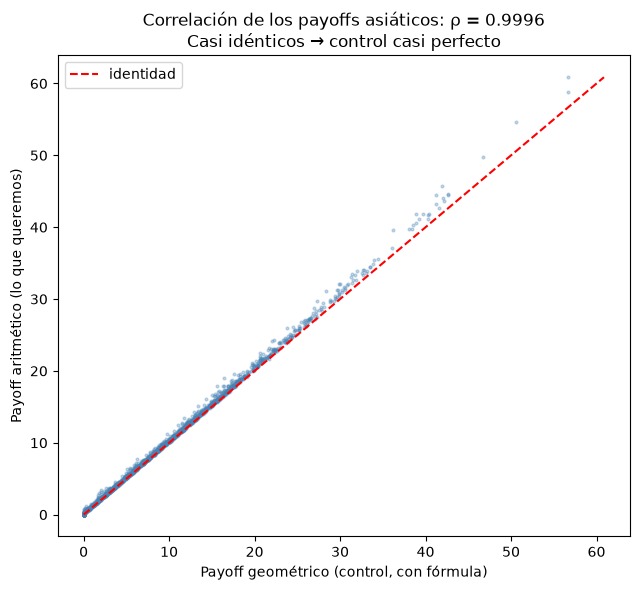

In [6]:
# Visualizamos la casi-perfecta correlación entre los dos payoffs
paths = simular_gbm(S0, r, sigma, T, m, 3000, rng)
monit = paths[:, 1:]
A = monit.mean(axis=1); G = np.exp(np.log(monit).mean(axis=1))
payA = np.maximum(A - K, 0.0); payG = np.maximum(G - K, 0.0)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(payG, payA, s=4, alpha=0.3, color='steelblue')
lim = max(payA.max(), payG.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='identidad')
ax.set_xlabel('Payoff geométrico (control, con fórmula)')
ax.set_ylabel('Payoff aritmético (lo que queremos)')
ax.set_title(f'Correlación de los payoffs asiáticos: ρ = {np.corrcoef(payA, payG)[0,1]:.4f}\nCasi idénticos → control casi perfecto')
ax.legend(); plt.tight_layout(); plt.show()

---

# Sección 4 — Griegas por Monte Carlo

Las **Griegas** son las sensibilidades del precio a los parámetros: $\Delta = \partial V/\partial S_0$ (cobertura direccional), $\Gamma = \partial^2 V/\partial S_0^2$ (convexidad) y $\mathcal{V} = \partial V/\partial \sigma$ (Vega, sensibilidad a la volatilidad). Son el pan de cada día de una mesa: sin ellas no se puede cubrir. Calcularlas por Monte Carlo tiene sutilezas, y hay tres enfoques.

Para la call europea tenemos las Griegas exactas de Black-Scholes como patrón:

$$
\Delta = \Phi(d_1), \qquad \Gamma = \frac{\phi(d_1)}{S_0\,\sigma\sqrt{T}}, \qquad \mathcal{V} = S_0\,\phi(d_1)\sqrt{T}
$$

In [7]:
def griegas_bs(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1), norm.pdf(d1) / (S0 * sigma * np.sqrt(T)), S0 * norm.pdf(d1) * np.sqrt(T)

delta_bs, gamma_bs, vega_bs = griegas_bs(S0, K, r, sigma, T)
print(f"Analíticas:  Delta = {delta_bs:.4f}   Gamma = {gamma_bs:.4f}   Vega = {vega_bs:.4f}")

Analíticas:  Delta = 0.6368   Gamma = 0.0188   Vega = 37.5240


## 4.1 Diferencias finitas (bump-and-revalue)

El método ingenuo: perturbar el parámetro y revalorar, $\Delta \approx [V(S_0+h) - V(S_0-h)]/(2h)$. La clave para que funcione es usar **los mismos números aleatorios** (*common random numbers*) en ambas valoraciones: si no, el ruido Monte Carlo de las dos valoraciones domina sobre la diferencia y el estimador es basura. Con CRN, funciona bien para Delta y Gamma.

In [8]:
def griegas_diferencias_finitas(S0, K, r, sigma, T, N, rng, h=0.5):
    Z = rng.standard_normal(N)   # MISMOS Z para todas las valoraciones (CRN)
    def precio(S):
        ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
        return np.exp(-r * T) * np.maximum(ST - K, 0.0).mean()
    v0, vp, vm = precio(S0), precio(S0 + h), precio(S0 - h)
    delta = (vp - vm) / (2 * h)
    gamma = (vp - 2 * v0 + vm) / h**2
    return delta, gamma

delta_fd, gamma_fd = griegas_diferencias_finitas(S0, K, r, sigma, T, 2_000_000, rng)
print(f"Dif. finitas (CRN):  Delta = {delta_fd:.4f}   Gamma = {gamma_fd:.4f}")
print(f"Analíticas:          Delta = {delta_bs:.4f}   Gamma = {gamma_bs:.4f}")

Dif. finitas (CRN):  Delta = 0.6370   Gamma = 0.0188
Analíticas:          Delta = 0.6368   Gamma = 0.0188


## 4.2 Método pathwise

En lugar de perturbar, **derivamos el payoff dentro de la esperanza** (intercambiando derivada e integral). Para la call, $\partial (S_T - K)^+/\partial S_0 = \mathbf{1}_{\{S_T > K\}} \cdot \partial S_T/\partial S_0 = \mathbf{1}_{\{S_T > K\}} \cdot S_T/S_0$, así que:

$$
\Delta_{\text{pw}} = e^{-rT}\,\mathbb{E}\!\left[\mathbf{1}_{\{S_T > K\}}\frac{S_T}{S_0}\right], \qquad
\mathcal{V}_{\text{pw}} = e^{-rT}\,\mathbb{E}\!\left[\mathbf{1}_{\{S_T > K\}}\,S_T\left(\sqrt{T}Z - \sigma T\right)\right]
$$

Es preciso y de baja varianza, **pero requiere que el payoff sea diferenciable**. Sirve para Delta y Vega de la call, pero **falla para Gamma** (la segunda derivada mete una delta de Dirac en el punto de no diferenciabilidad $S_T = K$).

In [9]:
def griegas_pathwise(S0, K, r, sigma, T, N, rng):
    Z = rng.standard_normal(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    ind = (ST > K).astype(float)
    delta = np.exp(-r * T) * np.mean(ind * ST / S0)
    vega = np.exp(-r * T) * np.mean(ind * ST * (np.sqrt(T) * Z - sigma * T))
    return delta, vega

delta_pw, vega_pw = griegas_pathwise(S0, K, r, sigma, T, 2_000_000, rng)
print(f"Pathwise:    Delta = {delta_pw:.4f}   Vega = {vega_pw:.4f}")
print(f"Analíticas:  Delta = {delta_bs:.4f}   Vega = {vega_bs:.4f}")

Pathwise:    Delta = 0.6373   Vega = 37.5750
Analíticas:  Delta = 0.6368   Vega = 37.5240


## 4.3 Razón de verosimilitud (likelihood ratio)

El tercer método deja el payoff intacto y **deriva la densidad** en vez del payoff. Pesa cada payoff por un "score" (la derivada del logaritmo de la densidad). Su gran ventaja: **funciona aunque el payoff no sea diferenciable**, así que es el método para Gamma. Su desventaja: mayor varianza. Para el GBM:

$$
\Delta_{\text{LR}} = e^{-rT}\,\mathbb{E}\!\left[\text{payoff}\cdot\frac{Z}{S_0\,\sigma\sqrt{T}}\right], \qquad
\Gamma_{\text{LR}} = e^{-rT}\,\mathbb{E}\!\left[\text{payoff}\cdot\frac{Z^2 - \sigma\sqrt{T}\,Z - 1}{S_0^2\,\sigma^2 T}\right]
$$

In [10]:
def griegas_likelihood_ratio(S0, K, r, sigma, T, N, rng):
    Z = rng.standard_normal(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.exp(-r * T) * np.maximum(ST - K, 0.0)
    sqrtT = np.sqrt(T)
    delta = np.mean(payoff * Z / (S0 * sigma * sqrtT))
    gamma = np.mean(payoff * (Z**2 - sigma * sqrtT * Z - 1) / (S0**2 * sigma**2 * T))
    return delta, gamma

delta_lr, gamma_lr = griegas_likelihood_ratio(S0, K, r, sigma, T, 2_000_000, rng)
print(f"Likelihood ratio:  Delta = {delta_lr:.4f}   Gamma = {gamma_lr:.4f}")
print(f"Analíticas:        Delta = {delta_bs:.4f}   Gamma = {gamma_bs:.4f}")

Likelihood ratio:  Delta = 0.6352   Gamma = 0.0186


Analíticas:        Delta = 0.6368   Gamma = 0.0188


## 4.4 Comparativa y cierre

Reunimos las tres estimaciones de cada Griega frente al valor exacto. Cada método tiene su nicho: pathwise es el más preciso donde aplica (Delta, Vega), la razón de verosimilitud es el único que da Gamma sin problemas, y las diferencias finitas son el recurso universal pero sesgado y ruidoso.

In [11]:
print(f"{'Griega':<8}{'Analítica':>12}{'Dif.finitas':>13}{'Pathwise':>11}{'Likel.ratio':>13}")
print("-" * 57)
print(f"{'Delta':<8}{delta_bs:>12.4f}{delta_fd:>13.4f}{delta_pw:>11.4f}{delta_lr:>13.4f}")
print(f"{'Gamma':<8}{gamma_bs:>12.4f}{gamma_fd:>13.4f}{'—  (falla)':>11}{gamma_lr:>13.4f}")
print(f"{'Vega':<8}{vega_bs:>12.4f}{'—':>13}{vega_pw:>11.4f}{'—':>13}")

Griega     Analítica  Dif.finitas   Pathwise  Likel.ratio
---------------------------------------------------------
Delta         0.6368       0.6370     0.6373       0.6352
Gamma         0.0188       0.0188 —  (falla)       0.0186
Vega         37.5240            —    37.5750            —


## Cierre del módulo

**Qué hemos construido.** El oficio del Monte Carlo aplicado: dos técnicas de reducción de varianza (antitéticas y variables de control) y las tres formas de calcular Griegas por simulación.

**Lo esencial.**

1. **Las variables de control son la técnica más potente** cuando existe un buen control. La asiática geométrica reduce la varianza de la aritmética en dos-tres órdenes de magnitud — una diferencia que en producción se traduce en segundos frente a horas de cómputo.
2. **No hay un método de Griegas universalmente mejor.** Pathwise gana en precisión donde el payoff es diferenciable; la razón de verosimilitud es el único que da Gamma limpiamente; las diferencias finitas siempre funcionan pero con sesgo y ruido. Un buen quant elige según el payoff.
3. **Todas estas técnicas son ortogonales a la elección del modelo:** funcionan igual sobre GBM que sobre modelos más ricos, y son exactamente lo que hace falta cuando se pasa de valorar a operar y cubrir en la práctica.

Este módulo, junto con el de opciones americanas y el de la sonrisa de volatilidad, completa el proyecto más allá de su núcleo, mostrando el dominio del método y no solo su concepto.

## Referencias

- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*, caps. 4 y 7.
- Kemna, A. & Vorst, A. (1990). *A Pricing Method for Options Based on Average Asset Values*. J. Banking & Finance, 14(1).
- Broadie, M. & Glasserman, P. (1996). *Estimating Security Price Derivatives Using Simulation*. Management Science, 42(2).